# Planetary PV versus topographic steering

This notebook tests whether tilt aligns with planetary PV gradients offshore but with topographic PV gradients over the shelf/slope. It reuses the established PV calculations in `seacofs_tilt_tools`; no PV formula is duplicated here.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
ANALYSIS_ROOT = HERE.parent
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(ANALYSIS_ROOT / "beta_effect_background_flow") not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT / "beta_effect_background_flow"))

import seacofs_tilt_tools as tilt
import mechanism_tools as mech

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = mech.require_tilt_measurements(df)
print(f"Rows: {len(df):,}; measured tilts: {df.TiltDis.notna().sum():,}; eddies: {df.Eddy.nunique():,}")


Rows: 127,426; measured tilts: 105,621; eddies: 2,982


In [2]:
data = tilt.add_pv_gradient_terms(df, grid)
data = tilt.add_region_labels(data, grid)
data = mech.add_topographic_regimes(data, shelf_depth=2000.0, dominance_ratio=2.0)

for reference in ["PV_grad_plan_theta", "PV_grad_topo_theta", "PV_grad_theta"]:
    data[f"signed_{reference}_offset"] = mech.signed_angle_difference(data["TiltDir"], data[reference])

offsets = ["signed_PV_grad_plan_theta_offset", "signed_PV_grad_topo_theta_offset", "signed_PV_grad_theta_offset"]
display(mech.circular_offset_summary(data, offsets, group=("Cyc", "ShelfRegime", "PVRegime")))


,Cyc,ShelfRegime,PVRegime,metric,eddies,mean_offset_deg,resultant_length,median_abs_offset_deg
0,AE,off_shelf,mixed,signed_PV_grad_plan_theta_offset,996,-172.497365,0.280772,184.720250
1,AE,off_shelf,mixed,signed_PV_grad_topo_theta_offset,996,107.079958,0.033448,174.650350
2,AE,off_shelf,mixed,signed_PV_grad_theta_offset,996,-178.487914,0.202460,181.428656
3,AE,off_shelf,planetary,signed_PV_grad_plan_theta_offset,524,-175.561068,0.238133,183.091162
4,AE,off_shelf,planetary,signed_PV_grad_topo_theta_offset,524,64.788995,0.047434,166.295894
5,AE,off_shelf,planetary,signed_PV_grad_theta_offset,524,-175.791218,0.225309,182.640223
6,AE,off_shelf,topographic,signed_PV_grad_plan_theta_offset,1224,-161.856367,0.329452,192.569651
7,AE,off_shelf,topographic,signed_PV_grad_topo_theta_offset,1224,-62.110776,0.060111,193.112874
8,AE,off_shelf,topographic,signed_PV_grad_theta_offset,1224,-112.247984,0.062440,193.241773
9,AE,on_shelf,mixed,signed_PV_grad_plan_theta_offset,259,165.535739,0.396276,163.356028


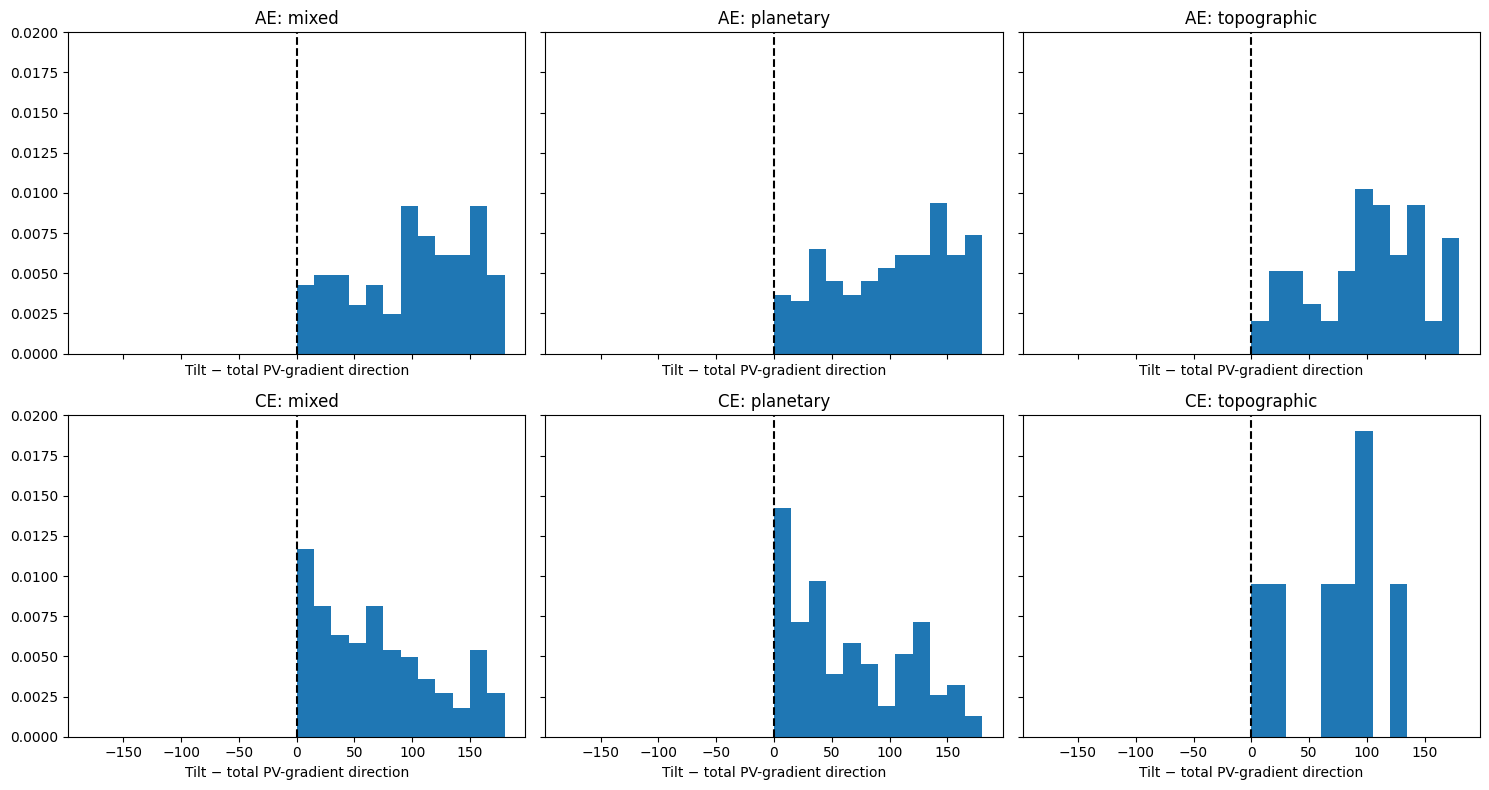

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, ((cyc, regime), part) in zip(axes.flat, data.groupby(["Cyc", "PVRegime"])):
    values = part.groupby("Eddy")["signed_PV_grad_theta_offset"].apply(tilt.circular_mean_deg_true_north)
    ax.hist(values, bins=np.arange(-180, 181, 15), density=True)
    ax.axvline(0, color="black", ls="--")
    ax.set(title=f"{cyc}: {regime}", xlabel="Tilt − total PV-gradient direction")
plt.tight_layout()


In [4]:
# Does topographic control strengthen with slope and eddy bottom contact?
data["slope_mag"] = np.hypot(data["dhdx"], data["dhdy"])
if "EddyDepth" in data:
    data["penetration_fraction"] = data["EddyDepth"].abs() / data["h"]
else:
    data["penetration_fraction"] = np.nan

summary = (data.groupby(["Cyc", "ShelfRegime", "PVRegime"])
           .agg(rows=("TiltDis", "size"), eddies=("Eddy", "nunique"),
                tilt_km=("TiltDis", "median"), slope=("slope_mag", "median"),
                topo_plan=("topo_plan_ratio_raw", "median"),
                abs_topo_offset=("signed_PV_grad_topo_theta_offset", lambda x: np.nanmedian(np.abs(x))))
           .reset_index())
display(summary)


,Cyc,ShelfRegime,PVRegime,rows,eddies,tilt_km,slope,topo_plan,abs_topo_offset
0,AE,off_shelf,mixed,18636,1071,16.056803,0.001756,1.148483,92.733454
1,AE,off_shelf,planetary,3958,593,14.232134,0.000615,0.347356,87.123351
2,AE,off_shelf,topographic,33489,1275,23.432326,0.007538,6.487890,87.534997
3,AE,on_shelf,mixed,3130,301,15.419444,0.002118,1.085974,87.733182
4,AE,on_shelf,planetary,974,178,11.773702,0.000790,0.331533,87.786325
5,AE,on_shelf,topographic,4765,311,20.541732,0.043869,30.543174,75.645610
6,CE,off_shelf,mixed,7638,884,13.989101,0.001124,1.346520,83.411431
7,CE,off_shelf,planetary,660,329,13.272843,0.000292,0.341617,91.126623
8,CE,off_shelf,topographic,40224,1315,18.193253,0.005999,7.897909,77.154684
9,CE,on_shelf,mixed,1567,321,11.041600,0.001082,1.335859,89.404577


## Strong topographic-steering evidence would be

- tighter topographic-PV alignment as slope and bottom influence increase;
- stronger alignment in topographic-dominant than planetary-dominant regimes;
- a distinct on-shelf response that is not reproduced offshore;
- deep-centre propagation following isobaths more strongly than surface propagation (tested next).
